#import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load the Dataset


In [2]:
df = pd.read_csv("../data/cardio_data.csv")

#Display first five Records

In [3]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal


#Understand Dataset Structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   68205 non-null  int64  
 1   age                  68205 non-null  int64  
 2   gender               68205 non-null  int64  
 3   height               68205 non-null  int64  
 4   weight               68205 non-null  float64
 5   ap_hi                68205 non-null  int64  
 6   ap_lo                68205 non-null  int64  
 7   cholesterol          68205 non-null  int64  
 8   gluc                 68205 non-null  int64  
 9   smoke                68205 non-null  int64  
 10  alco                 68205 non-null  int64  
 11  active               68205 non-null  int64  
 12  cardio               68205 non-null  int64  
 13  age_years            68205 non-null  int64  
 14  bmi                  68205 non-null  float64
 15  bp_category          68205 non-null 

#Check Dataset Shape

In [5]:
df.shape

(68205, 17)

#Display Column Names

In [6]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years',
       'bmi', 'bp_category', 'bp_category_encoded'],
      dtype='object')

#Check Null Values

In [7]:
df.isnull().sum()

id                     0
age                    0
gender                 0
height                 0
weight                 0
ap_hi                  0
ap_lo                  0
cholesterol            0
gluc                   0
smoke                  0
alco                   0
active                 0
cardio                 0
age_years              0
bmi                    0
bp_category            0
bp_category_encoded    0
dtype: int64

#Check Total Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

#Drop Identifier

In [9]:
df.drop(columns=["id"], inplace=True)

#Display Blood Pressure Category Distribution

In [10]:
df["bp_category"].value_counts()

bp_category
Hypertension Stage 1    39750
Hypertension Stage 2    15937
Normal                   9417
Elevated                 3101
Name: count, dtype: int64

#Display Encoded Blood Pressure Category Distribution

In [11]:
df["bp_category_encoded"].value_counts()

bp_category_encoded
Hypertension Stage 1    39750
Hypertension Stage 2    15937
Normal                   9417
Elevated                 3101
Name: count, dtype: int64

#Display Data Type of Blood Pressure Category Features

In [12]:
df[["bp_category", "bp_category_encoded"]].dtypes

bp_category            object
bp_category_encoded    object
dtype: object

#Drop Duplicate Blood Pressure Category Featur

In [13]:
df.drop(columns = "bp_category_encoded",inplace=True)

#Compare Age and Age in Years

In [14]:
df[['age', 'age_years']].head(10)

,age,age_years
0,18393,50
1,20228,55
2,18857,51
3,17623,48
4,17474,47
5,21914,60
6,22113,60
7,22584,61
8,17668,48
9,19834,54


#Drop Age Feature Measured in Days

In [15]:
df.drop(columns='age',inplace=True)

#Import ScorecardPy Library for WOE and IV

In [16]:
import scorecardpy as sc

d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


#Calculate Weight Of Evidence

In [ ]:
bins = sc.woebin(df, y='cardio')

#Apply WOE Transformation

In [28]:
df_woe = sc.woebin_ply(df,bins)
df_woe.head()

[INFO] converting into woe values ...


,cardio,weight_woe,gluc_woe,alco_woe,ap_lo_woe,age_years_woe,smoke_woe,ap_hi_woe,bmi_woe,gender_woe,active_woe,bp_category_woe,height_woe,cholesterol_woe
0,0,-0.241999,-0.075721,0.004282,-0.276515,-0.360289,0.010271,-1.179069,-0.483279,0.016669,-0.037539,-0.181980,-0.029767,-0.237229
1,1,0.265247,-0.075721,0.004282,1.113552,0.278917,0.010271,1.660951,0.629898,-0.008923,-0.037539,1.416020,0.071197,1.185740
2,1,-0.241999,-0.075721,0.004282,-0.933186,-0.075352,0.010271,0.425017,-0.181213,-0.008923,0.153643,-0.181980,-0.091504,1.185740
3,1,0.265247,-0.075721,0.004282,1.673540,-0.360289,0.010271,1.660951,0.207200,0.016669,-0.037539,1.416020,-0.029767,-0.237229
4,0,-0.603890,-0.075721,0.004282,-0.933186,-0.360289,0.010271,-1.179069,-0.181213,-0.008923,0.153643,-1.091124,0.071197,-0.237229


#Display Information Values (IV) of Features

In [29]:
df_iv = sc.iv(df, y="cardio")
df_iv

,variable,info_value
6,ap_hi,1.012662
10,bp_category,0.632878
3,ap_lo,0.600489
7,bmi,0.285261
4,age_years,0.261406
12,cholesterol,0.209556
0,weight,0.144780
1,gluc,0.033580
11,height,0.005958
9,active,0.005765


#Remove Columns with Low IV

In [30]:
df_woe = df_woe.drop(
    columns=[
        'height_woe',
        'active_woe',
        'smoke_woe',
        'alco_woe',
        'gender_woe'
    ]
)

#Display Remaining WOE Features

In [31]:
df_woe.columns

Index(['cardio', 'weight_woe', 'gluc_woe', 'ap_lo_woe', 'age_years_woe',
       'ap_hi_woe', 'bmi_woe', 'bp_category_woe', 'cholesterol_woe'],
      dtype='object')

#Import library for VIF Calculation

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Select Independent Variables

In [34]:
X = df_woe.drop(columns='cardio')

#Calculate VIF For Each Feature

In [37]:
vif = pd.DataFrame()

vif['features'] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values,i)
    for i in range(X.shape[1])
]

vif

,features,VIF
0,weight_woe,2.696992
1,gluc_woe,1.232133
2,ap_lo_woe,4.277256
3,age_years_woe,1.064686
4,ap_hi_woe,2.771158
5,bmi_woe,2.723557
6,bp_category_woe,4.987015
7,cholesterol_woe,1.294488


#Update Feature Matrix

In [38]:
X = df_woe.drop(columns='cardio')
y = df_woe['cardio']

#Split Data Into Training and Testing Sets

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state=42,
    stratify=y
)

#Import Logistic Regression and GridSearchCV

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Create Logistic Regression Model

In [41]:
log_model = LogisticRegression(max_iter=1000)

#Define Hyperparameter Grid

In [42]:
param_grid = {
    "C" : [0.01, 0.1, 1, 10],
    "solver" : ["liblinear", "lbfgs"]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [43]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

#Train Logistic Regression Model

In [44]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pri

#Display Best Hyperparameters

In [45]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'C': 0.1, 'solver': 'lbfgs'}
Best F1 Score : 0.700652865557411


#Predict Target Values on Test Data

In [46]:
y_pred = grid_search.predict(X_test)

#Import Model Evaluation Metrics

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#Evaluate Logistic Regression Model

In [48]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.7318203143326296
Precision : 0.7646977832851439
Recall : 0.659776669042528
F1 : 0.7083731904853007


#Display Confusion Matrix

In [49]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[6925 1709]
 [2864 5554]]


#Display Classification Report

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.80      0.75      8634
           1       0.76      0.66      0.71      8418

    accuracy                           0.73     17052
   macro avg       0.74      0.73      0.73     17052
weighted avg       0.74      0.73      0.73     17052



#Import Decision Tree and GridSearchCV

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

#Create Decision Tree Classifier

In [52]:
dt_model = DecisionTreeClassifier(random_state=42)

#Define Hyperparameters for Decision Tree

In [53]:
param_grid = {
    "criterion" : ['gini', 'entropy'],
    "max_depth" : [3, 5, 7, 10],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [54]:
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

#Train Decision Tree Model

In [55]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

#Display Best Hyperparameters

In [56]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best F1 Score : 0.7101993837445547


#Predict Target Values on Test Dataset

In [57]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#Evaluate Decision Tree Model

In [60]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.7352216748768473
Precision : 0.7481246026700572
Recall : 0.6989783796626277
F1 : 0.7227169440520789


#Display Confusion Matrix

In [61]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[6653 1981]
 [2534 5884]]


#Display Classification Report

In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.77      0.75      8634
           1       0.75      0.70      0.72      8418

    accuracy                           0.74     17052
   macro avg       0.74      0.73      0.73     17052
weighted avg       0.74      0.74      0.73     17052



#Display Feature Importance

In [63]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

           Feature  Importance
4        ap_hi_woe    0.745687
3    age_years_woe    0.130400
7  cholesterol_woe    0.075937
5          bmi_woe    0.018741
1         gluc_woe    0.009845
0       weight_woe    0.008598
2        ap_lo_woe    0.007957
6  bp_category_woe    0.002835


### This tells us which features contributed the most to the Decision Tree.

#Visualize Decision Tree

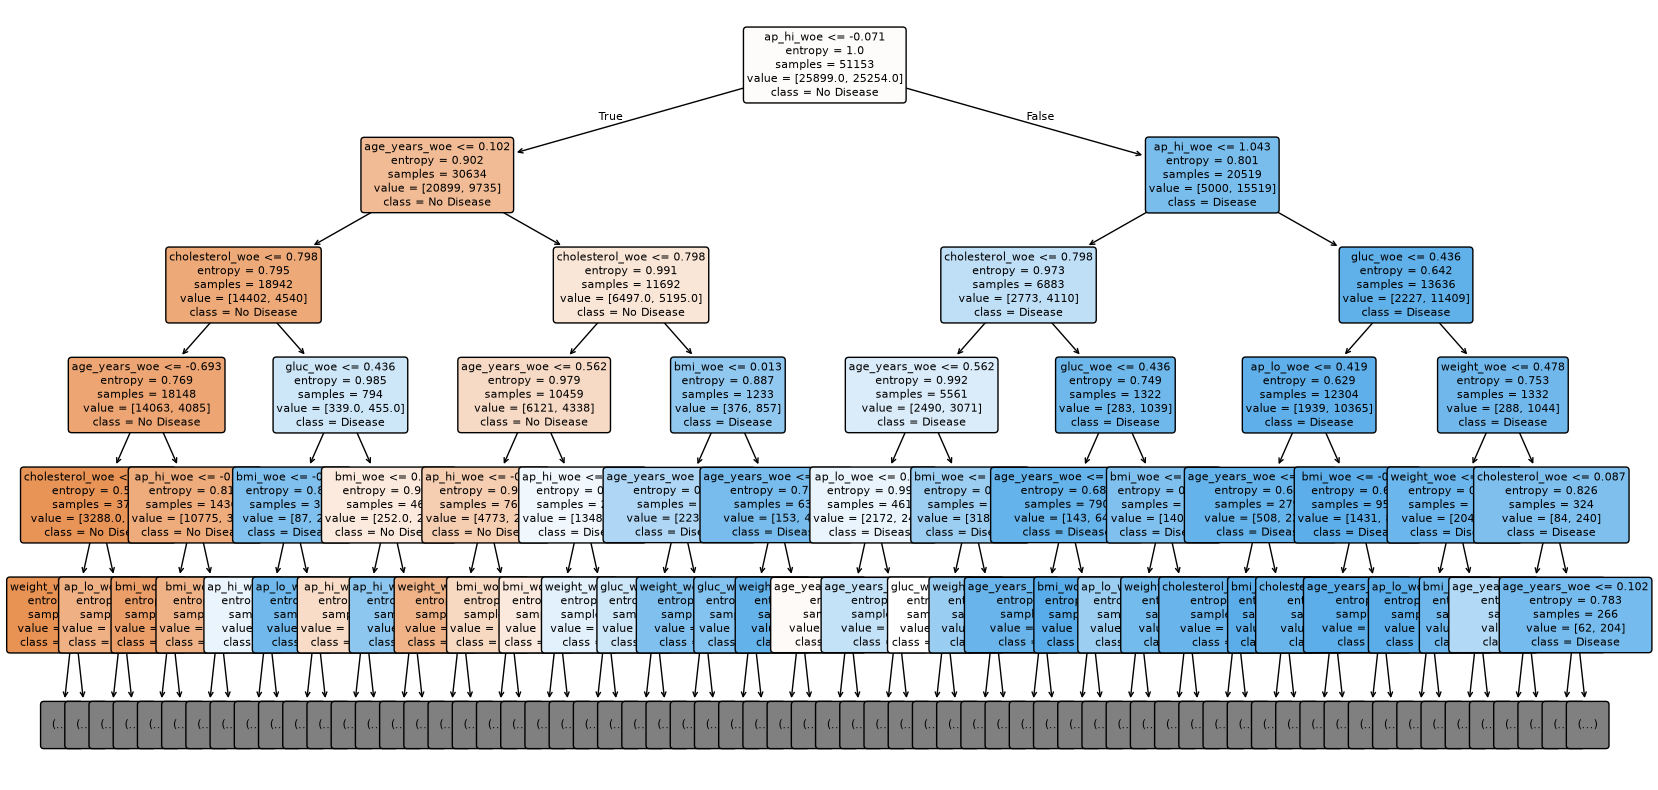

In [64]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    grid_search.best_estimator_,
    feature_names = X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    max_depth=5,
    fontsize=8
)

plt.show()

## Final Conclusion

Conclusion

Both models performed well on the cardiovascular disease prediction dataset. Logistic Regression achieved the highest precision, whereas Decision Tree provided better overall performance with higher accuracy, recall, and F1-score.

Based on these evaluation metrics, the Decision Tree model was selected as the final model because it offers a better balance between identifying positive cases and maintaining overall predictive performance.